## Group Details
### 1. Batch Name: Batch_A_AWS | P02
### 2. Group Name: Insurance Industry
### 3. Group Members: Piyush Kumar

## 0. Installing Libraries

In [69]:
# pip install numpy
# pip install pandas
# pip install seaborn
# pip install matplotlib

## 1. Importing libraries & dataset

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, HTML

In [71]:
df_insurance_claim = pd.read_csv("./../input/01_Insurance claim.csv")
df_car_features = pd.read_csv("./../input/02_Car features.csv")
df_policy_features = pd.read_csv("./../input/03_Policy features.csv")

## 2. Dataset Overview

In [72]:
df_insurance_claim.info()

<class 'pandas.DataFrame'>
RangeIndex: 58515 entries, 0 to 58514
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   policy_id  58515 non-null  str  
 1   is_claim   58515 non-null  int64
dtypes: int64(1), str(1)
memory usage: 914.4 KB


In [73]:
df_car_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 58515 entries, 0 to 58514
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   policy_id                         58515 non-null  str    
 1   make                              58515 non-null  float64
 2   segment                           58515 non-null  str    
 3   model                             58515 non-null  str    
 4   fuel_type                         58489 non-null  str    
 5   max_torque                        58508 non-null  str    
 6   max_power                         58512 non-null  str    
 7   engine_type                       58512 non-null  str    
 8   airbags                           58506 non-null  float64
 9   is_esc                            58512 non-null  str    
 10  is_adjustable_steering            58508 non-null  str    
 11  is_tpms                           58512 non-null  str    
 12  is_parking_sens

In [74]:
df_policy_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 58515 entries, 0 to 58514
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   policy_id            58515 non-null  str    
 1   policy_tenure        58495 non-null  float64
 2   age_of_car           58510 non-null  float64
 3   age_of_policyholder  58508 non-null  float64
 4   area_cluster         58509 non-null  str    
 5   population_density   58503 non-null  float64
dtypes: float64(4), str(2)
memory usage: 2.7 MB


In [75]:
df_insurance_claim.head(5)

,policy_id,is_claim
0,ID00001,0
1,ID00002,0
2,ID00003,0
3,ID00004,0
4,ID00005,0


In [76]:
df_car_features.head(5)

,policy_id,make,segment,model,fuel_type,max_torque,max_power,engine_type,airbags,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,rear_brakes_type,displacement,cylinder,transmission_type,gear_box,steering_type,turning_radius,length,width,height,gross_weight,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating
0,ID00001,1.0,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2.0,No,No,No,Yes,No,Drum,796.0,3.0,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0
1,ID00002,1.0,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2.0,No,No,No,Yes,No,Drum,796.0,3.0,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0
2,ID00003,1.0,A,M1,CNG,60Nm@3500rpm,40.36bhp@6000rpm,F8D Petrol Engine,2.0,No,No,No,Yes,No,Drum,796.0,3.0,Manual,5,Power,4.6,3445,1515,1475,1185,No,No,No,No,No,No,No,Yes,No,No,No,Yes,0
3,ID00004,1.0,C1,M2,Petrol,113Nm@4400rpm,88.50bhp@6000rpm,1.2 L K12N Dualjet,2.0,Yes,Yes,No,Yes,Yes,Drum,1197.0,4.0,Automatic,5,Electric,4.8,3995,1735,1515,1335,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,2
4,ID00005,2.0,A,M3,Petrol,91Nm@4250rpm,67.06bhp@5500rpm,1.0 SCe,2.0,No,No,No,No,Yes,Drum,999.0,3.0,Automatic,5,Electric,5.0,3731,1579,1490,1155,No,No,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,2


In [77]:
df_policy_features.head(5)

,policy_id,policy_tenure,age_of_car,age_of_policyholder,area_cluster,population_density
0,ID00001,0.515874,0.05,0.644231,C1,4990.0
1,ID00002,0.672619,0.02,0.375000,C2,27003.0
2,ID00003,0.841110,0.02,0.384615,C3,4076.0
3,ID00004,0.900277,0.11,0.432692,C4,21622.0
4,ID00005,0.596403,0.11,0.634615,C5,34738.0


## Duplicate Analysis
Check for exact duplicate rows and duplicate policy_id values in all three dataframes.

In [78]:
dataframes = {
    "df_insurance_claim": df_insurance_claim,
    "df_car_features": df_car_features,
    "df_policy_features": df_policy_features
}


### Duplicate Summary

In [79]:
summary = []

for name, df in dataframes.items():
    summary.append({
        "dataframe": name,
        "total_rows": len(df),
        "unique_policy_ids": df["policy_id"].nunique(),
        "exact_duplicate_rows": df.duplicated().sum(),
        "duplicate_policy_id_rows": df.duplicated(
            subset="policy_id"
        ).sum(),
        "policy_id_is_unique": df["policy_id"].is_unique
    })

duplicate_summary = pd.DataFrame(summary)

display(duplicate_summary)


,dataframe,total_rows,unique_policy_ids,exact_duplicate_rows,duplicate_policy_id_rows,policy_id_is_unique
0,df_insurance_claim,58515,58515,0,0,True
1,df_car_features,58515,58515,0,0,True
2,df_policy_features,58515,58515,0,0,True


### View Duplicate policy_id Records

In [80]:
for name, df in dataframes.items():
    duplicate_policy_rows = (
        df[df.duplicated("policy_id", keep=False)]
        .sort_values("policy_id")
    )

    print(f"\n{name}")

    if duplicate_policy_rows.empty:
        print("No duplicate policy_id values found.")
    else:
        display(duplicate_policy_rows)



df_insurance_claim
No duplicate policy_id values found.

df_car_features
No duplicate policy_id values found.

df_policy_features
No duplicate policy_id values found.


## 3. Breakdown of Dataset

In [81]:
df_insurance_claim.describe()

,is_claim
count,58515.000000
mean,0.063967
std,0.244695
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [82]:
df_car_features.describe()

,make,airbags,displacement,cylinder,gear_box,turning_radius,length,width,height,gross_weight,ncap_rating
count,58515.000000,58506.000000,58508.000000,58508.000000,58515.000000,58515.000000,58515.000000,58515.000000,58515.000000,58515.000000,58515.000000
mean,1.763479,3.136362,1162.289106,3.626923,5.245305,4.852805,3850.377510,1672.212287,1553.322960,1385.226198,1.759788
std,1.137011,1.832328,266.302251,0.483627,0.430271,0.228039,311.434859,112.092562,79.623606,212.387541,1.389734
min,1.000000,1.000000,796.000000,3.000000,5.000000,4.500000,3445.000000,1475.000000,1475.000000,1051.000000,0.000000
25%,1.000000,2.000000,796.000000,3.000000,5.000000,4.600000,3445.000000,1515.000000,1475.000000,1185.000000,0.000000
50%,1.000000,2.000000,1197.000000,4.000000,5.000000,4.800000,3845.000000,1735.000000,1530.000000,1335.000000,2.000000
75%,3.000000,6.000000,1493.000000,4.000000,5.000000,5.000000,3995.000000,1755.000000,1635.000000,1510.000000,3.000000
max,5.000000,6.000000,1498.000000,4.000000,6.000000,5.200000,4300.000000,1811.000000,1825.000000,1720.000000,5.000000


In [83]:
df_policy_features.describe()

,policy_tenure,age_of_car,age_of_policyholder,population_density
count,58495.000000,58510.000000,58508.000000,58503.000000
mean,0.611175,0.069413,0.469423,18828.559817
std,0.414092,0.056726,0.122901,17661.056419
min,0.002735,0.000000,0.288462,290.000000
25%,0.210247,0.020000,0.365385,6112.000000
50%,0.573766,0.060000,0.451923,8794.000000
75%,1.038968,0.110000,0.548077,27003.000000
max,1.396641,1.000000,1.000000,73430.000000


## 4. Checking Null values in dataset

In [84]:
print(df_insurance_claim.isnull().sum())

policy_id    0
is_claim     0
dtype: int64


In [85]:
print(df_car_features.isnull().sum())

policy_id                            0
make                                 0
segment                              0
model                                0
fuel_type                           26
max_torque                           7
max_power                            3
engine_type                          3
airbags                              9
is_esc                               3
is_adjustable_steering               7
is_tpms                              3
is_parking_sensors                   7
is_parking_camera                    3
rear_brakes_type                     0
displacement                         7
cylinder                             7
transmission_type                    0
gear_box                             0
steering_type                        0
turning_radius                       0
length                               0
width                                0
height                               0
gross_weight                         0
is_front_fog_lights      

In [86]:
print(df_policy_features.isnull().sum())

policy_id               0
policy_tenure          20
age_of_car              5
age_of_policyholder     7
area_cluster            6
population_density     12
dtype: int64


## 5. Pearson correlation (Linear Correlation Analysis)
- 1.00 = strong positive linear relationship
- -1.00 = strong negative linear relationship
- 0.00 = little or no linear relationship

5.1. Pearson Correlation among Car Features

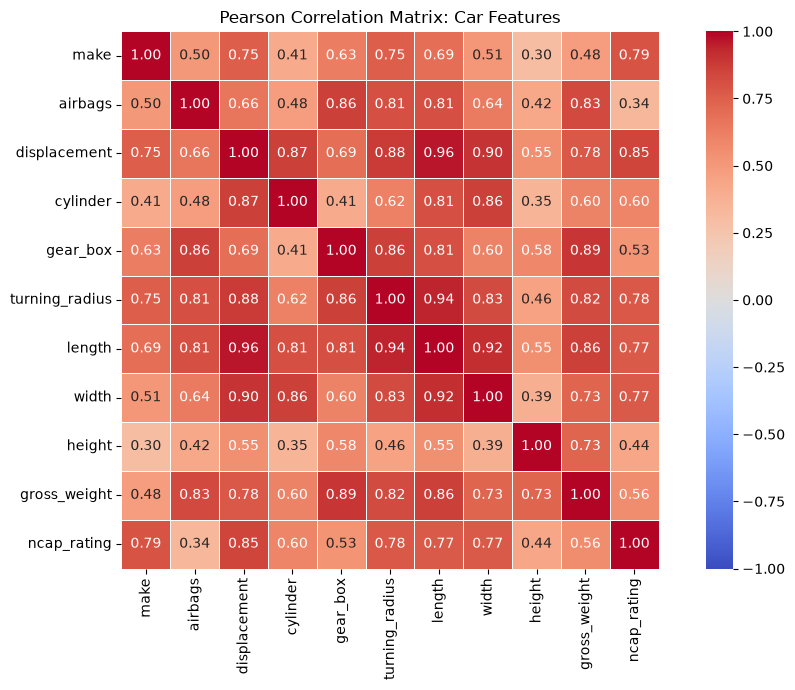

In [87]:
numeric_data = df_car_features.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_data.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix: Car Features")
plt.tight_layout()
plt.show()


5.2. Pearson Correlation among Policy Features

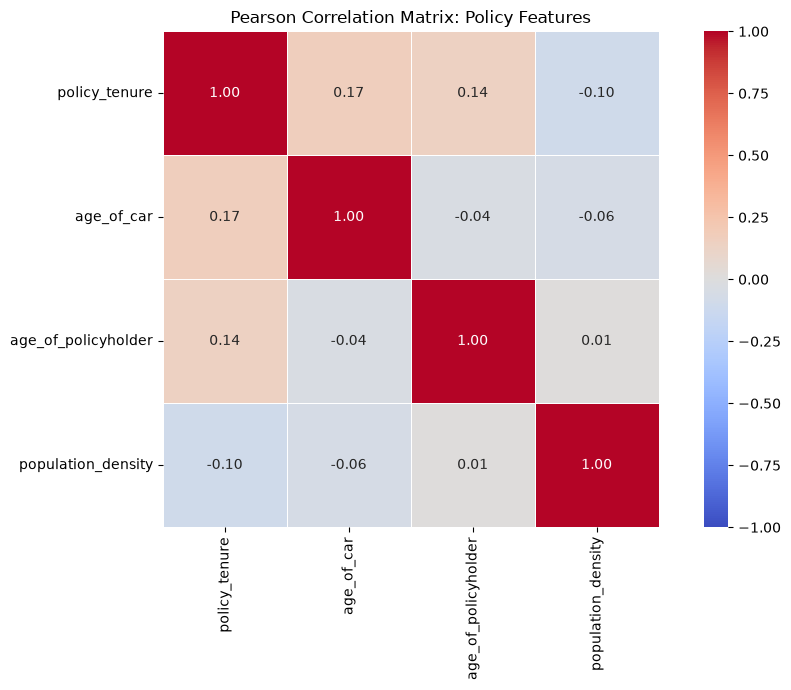

In [88]:
numeric_data = df_policy_features.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_data.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix: Policy Features")
plt.tight_layout()
plt.show()


5.3. Pearson Correlation among "Is Policy Claimed" and "Car Features"

In [89]:
df_merged_car_features = pd.merge(df_insurance_claim, df_car_features, on="policy_id", how="inner")

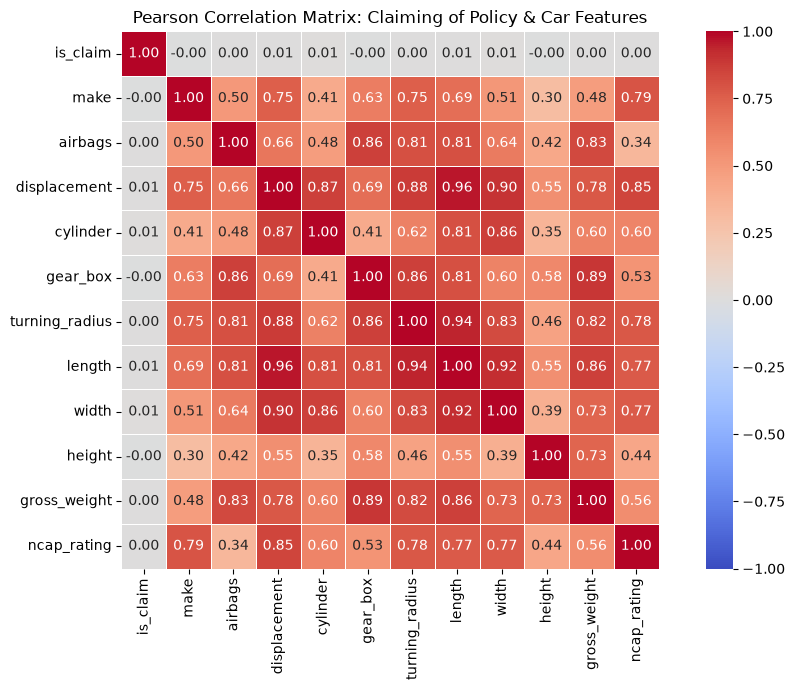

In [90]:
numeric_data = df_merged_car_features.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_data.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix: Claiming of Policy & Car Features")
plt.tight_layout()
plt.show()


5.4. Pearson Correlation among "Is Policy Claimed" and "Policy Features"

In [91]:
df_merged_policy_features = pd.merge(df_insurance_claim, df_policy_features, on="policy_id", how="inner")

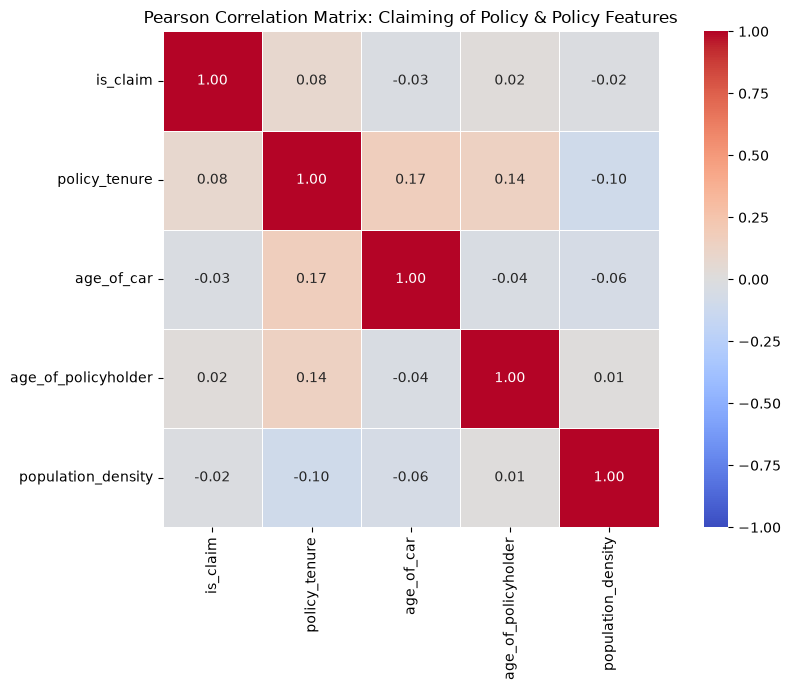

In [92]:
numeric_data = df_merged_policy_features.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_data.corr()

# Plot correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix: Claiming of Policy & Policy Features")
plt.tight_layout()
plt.show()


5.5. Pearson Correlation Matrix: Claiming of Policy, Car Features and Policy Features

In [93]:
df_merged_all = pd.merge(df_merged_policy_features, df_car_features, on="policy_id", how="inner")

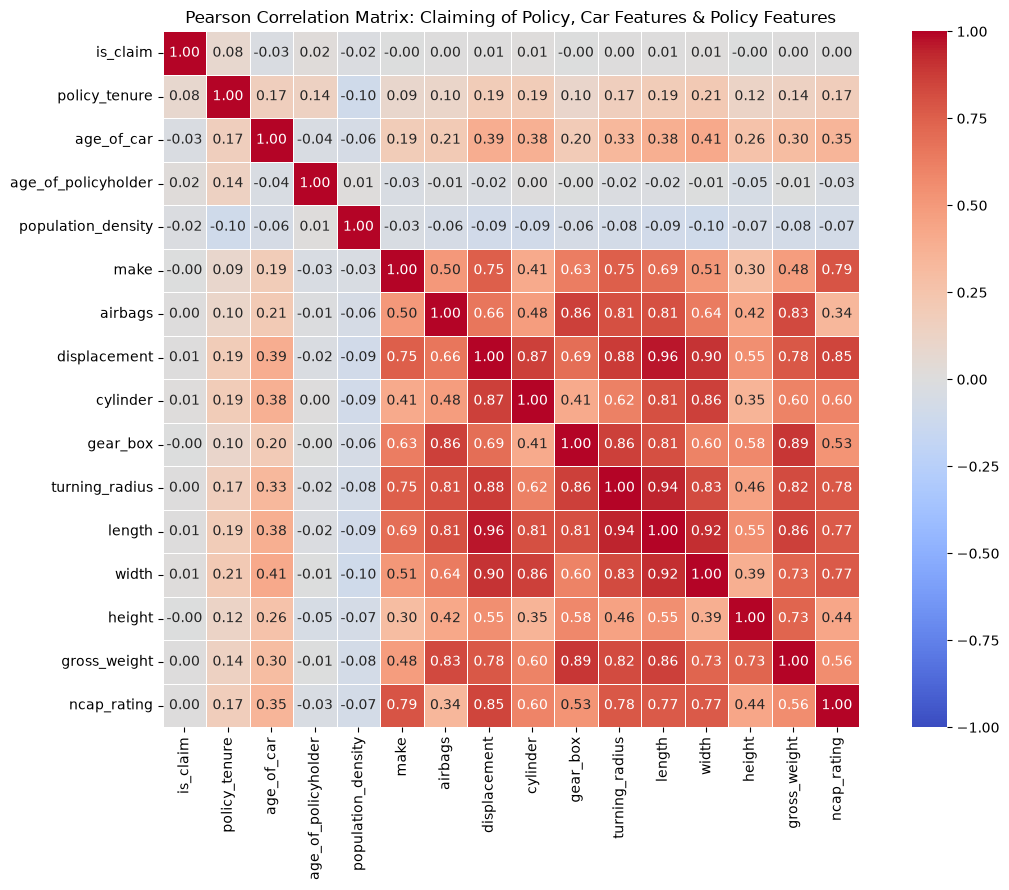

In [94]:
numeric_data = df_merged_all.select_dtypes(include="number")

# Calculate correlations
correlation_matrix = numeric_data.corr()

# Plot correlation matrix
plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix: Claiming of Policy, Car Features & Policy Features")
plt.tight_layout()
plt.show()


## Observations & Results from Pearson Correlation
- Claiming of Policy doesn't establish strong linear relationships with any other features as coefficient values lies between (-0.14, 0.17)

## 6. Spearman Correlation Analysis

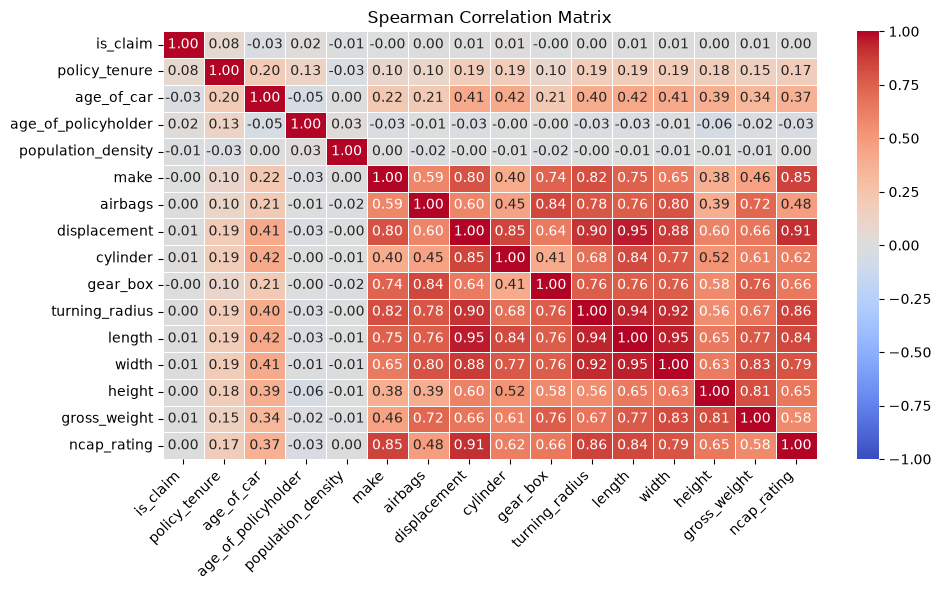

In [95]:
numeric_df = df_merged_all.select_dtypes(include="number").drop(
    columns="policy_id",
    errors="ignore"
)

# Calculate Spearman correlation
spearman_corr = numeric_df.corr(method="spearman")

# Plot correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(
    spearman_corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Observations & Results from Spearman Correlation
- Claiming of Policy doesn't establish strong linear relationships with any other features.

## 9. Overview of "Policy Claimed Or Not" distribution

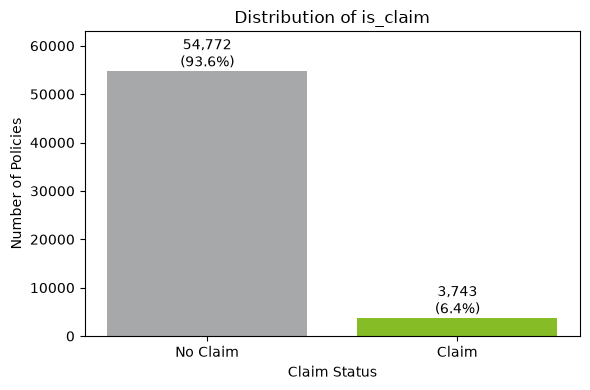

In [96]:
claims = pd.to_numeric(df_insurance_claim["is_claim"], errors="coerce").dropna()
claims = claims[claims.isin([0, 1])]

counts = claims.value_counts().reindex([0, 1], fill_value=0)
percentages = counts / counts.sum() * 100

labels = ["No Claim", "Claim"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color=["#A7A8AA", "#86BC25"])

for bar, count, percentage in zip(bars, counts, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Distribution of is_claim")
ax.set_xlabel("Claim Status")
ax.set_ylabel("Number of Policies")
ax.set_ylim(0, max(counts.max() * 1.15, 1))

plt.tight_layout()
plt.show()


## The dataset is imbalanced: Due to high disparity in "No Claim" and "Claim"

## 10. Claim Rate Analysis
1. Goal: Analyse whether policy and car features are associated with insurance claims.

2. Approach used
- Combine the three dataframes using policy_id.
- Select one feature.
- Calculate its claim rate.
- Compare it with the overall claim rate of approximately 6.4%.

Because is_claim contains only 0 and 1, its average directly gives the claim rate.

# 10.1. Merge the DataFrames

In [97]:
df_analysis = (
    df_insurance_claim
    .merge(
        df_policy_features,
        on="policy_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        df_car_features,
        on="policy_id",
        how="left",
        validate="one_to_one"
    )
)

print("Rows:", len(df_analysis))
print("Columns:", len(df_analysis.columns))

Rows: 58515
Columns: 44


## 10.2. Overall Claim Rate
This is the baseline used to compare every feature category.

In [98]:
overall_claim_rate = df_analysis["is_claim"].mean() * 100

print(f"Overall claim rate: {overall_claim_rate:.2f}%")

Overall claim rate: 6.40%


## 10.3. Claim Rate by Categorical Features

- Compare categories such as area cluster, segment, fuel type, and safety features.

In [99]:
categorical_features = (
    df_analysis
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .difference(["policy_id", "max_torque", "max_power"])
    .tolist()
)

# "make" is numeric but represents a car manufacturer category
if "make" not in categorical_features:
    categorical_features.append("make")

minimum_policies = 100
categorical_results = []

for feature in categorical_features:
    temp = pd.DataFrame({
        "category": df_analysis[feature].astype("string").fillna("Missing"),
        "is_claim": df_analysis["is_claim"]
    })

    result = (
        temp
        .groupby("category", observed=True)["is_claim"]
        .agg(
            policies="size",
            claims="sum",
            claim_rate="mean"
        )
        .reset_index()
    )

    result = result[result["policies"] >= minimum_policies].copy()

    result["feature"] = feature
    result["claim_rate_%"] = result["claim_rate"] * 100
    result["difference_from_average_pp"] = (
        result["claim_rate_%"] - overall_claim_rate
    )

    categorical_results.append(
        result[
            [
                "feature",
                "category",
                "policies",
                "claims",
                "claim_rate_%",
                "difference_from_average_pp"
            ]
        ]
    )

categorical_claim_rates = (
    pd.concat(categorical_results, ignore_index=True)
    .sort_values(["feature", "claim_rate_%"], ascending=[True, False])
)

categorical_claim_rates["claim_rate_%"] = (
    categorical_claim_rates["claim_rate_%"].round(2)
)

categorical_claim_rates["difference_from_average_pp"] = (
    categorical_claim_rates["difference_from_average_pp"].round(2)
)

print(f"Overall claim rate: {overall_claim_rate:.2f}%")


Overall claim rate: 6.40%


## View the Full Categorical Output

In [100]:
display(
    HTML(
        "<div style='max-height:600px; overflow:auto; border:1px solid #ccc;'>"
        + categorical_claim_rates.to_html(index=False)
        + "</div>"
    )
)

feature,category,policies,claims,claim_rate_%,difference_from_average_pp
area_cluster,C18,240,25,10.42,4.02
area_cluster,C22,207,17,8.21,1.82
area_cluster,C14,3652,281,7.69,1.30
area_cluster,C4,664,51,7.68,1.28
area_cluster,C21,379,29,7.65,1.26
area_cluster,C19,951,71,7.47,1.07
area_cluster,C3,6095,433,7.10,0.71
area_cluster,C2,7335,520,7.09,0.69
area_cluster,C8,13630,953,6.99,0.60
area_cluster,C6,888,55,6.19,-0.20


## The output shows:

- feature: Column name, for example area_cluster
- category: Specific value, for example C18
- policies: Number of policies in that category
- claims: Number of claims
- claim_rate_%: Claim rate for that category
- difference_from_average_pp: Difference from the overall claim rate

## 10.4. Rank Features by Claim Rate Variation

A feature is more useful for investigation when its categories have noticeably different claim rates.

# Compare Features, Not Individual Categories

In [101]:
feature_summary = (
    categorical_claim_rates
    .groupby("feature")
    .agg(
        lowest_claim_rate=("claim_rate_%", "min"),
        highest_claim_rate=("claim_rate_%", "max"),
        claim_rate_range=("claim_rate_%", lambda x: x.max() - x.min()),
        number_of_categories=("category", "nunique")
    )
    .reset_index()
    .sort_values("claim_rate_range", ascending=False)
)

feature_summary["lowest_claim_rate"] = (
    feature_summary["lowest_claim_rate"].round(2)
)

feature_summary["highest_claim_rate"] = (
    feature_summary["highest_claim_rate"].round(2)
)

feature_summary["claim_rate_range"] = (
    feature_summary["claim_rate_range"].round(2)
)

display(feature_summary)


,feature,lowest_claim_rate,highest_claim_rate,claim_rate_range,number_of_categories
0,area_cluster,3.86,10.42,6.56,22
1,engine_type,4.13,7.41,3.28,11
21,model,4.13,7.41,3.28,11
18,is_speed_alert,4.13,6.41,2.28,2
20,make,5.41,6.68,1.27,5
12,is_parking_sensors,5.37,6.44,1.07,2
23,segment,5.85,6.86,1.01,6
3,is_adjustable_steering,5.97,6.67,0.70,2
24,steering_type,6.04,6.69,0.65,3
10,is_front_fog_lights,6.06,6.64,0.58,2


## 10.5. Claim Rate by Numeric Features

Numeric features are divided into five groups so that claim rates can be compared fairly.

## How to Interpret the Results

Compare every claim rate with the overall claim rate of 6.40%.

- Claim rate above 6.40%: higher-than-average claim rate
- Claim rate below 6.40%: lower-than-average claim rate
- Positive difference: higher than average
- Negative difference: lower than average
- Larger claim-rate range: feature may be more useful for investigation

These results show association, not proof that a feature causes claims.


In [102]:
numeric_features = [
    "policy_tenure",
    "age_of_car",
    "age_of_policyholder",
    "population_density",
    "airbags",
    "displacement",
    "cylinder",
    "gear_box",
    "turning_radius",
    "length",
    "width",
    "height",
    "gross_weight",
    "ncap_rating"
]

numeric_features = [
    feature
    for feature in numeric_features
    if feature in df_analysis.columns
]

numeric_results = []

for feature in numeric_features:
    temp = df_analysis[[feature, "is_claim"]].dropna().copy()

    temp["value_group"] = pd.qcut(
        temp[feature],
        q=5,
        duplicates="drop"
    )

    result = (
        temp
        .groupby("value_group", observed=True)["is_claim"]
        .agg(
            policies="size",
            claims="sum",
            claim_rate="mean"
        )
        .reset_index()
    )

    result = result[result["policies"] >= minimum_policies].copy()

    result["feature"] = feature
    result["claim_rate_%"] = result["claim_rate"] * 100
    result["difference_from_average_pp"] = (
        result["claim_rate_%"] - overall_claim_rate
    )

    numeric_results.append(
        result[
            [
                "feature",
                "value_group",
                "policies",
                "claims",
                "claim_rate_%",
                "difference_from_average_pp"
            ]
        ]
    )

numeric_claim_rates = (
    pd.concat(numeric_results, ignore_index=True)
    .sort_values(["feature", "claim_rate_%"], ascending=[True, False])
)

numeric_claim_rates["claim_rate_%"] = (
    numeric_claim_rates["claim_rate_%"].round(2)
)

numeric_claim_rates["difference_from_average_pp"] = (
    numeric_claim_rates["difference_from_average_pp"].round(2)
)

display(numeric_claim_rates)


,feature,value_group,policies,claims,claim_rate_%,difference_from_average_pp
5,age_of_car,"(-0.001, 0.02]",16793,1166,6.94,0.55
7,age_of_car,"(0.04, 0.08]",11993,810,6.75,0.36
8,age_of_car,"(0.08, 0.12]",10696,700,6.54,0.15
6,age_of_car,"(0.02, 0.04]",8164,519,6.36,-0.04
9,age_of_car,"(0.12, 1.0]",10864,548,5.04,-1.35
14,age_of_policyholder,"(0.567, 1.0]",11662,822,7.05,0.65
12,age_of_policyholder,"(0.423, 0.49]",11575,790,6.83,0.43
13,age_of_policyholder,"(0.49, 0.567]",10516,685,6.51,0.12
11,age_of_policyholder,"(0.356, 0.423]",11841,723,6.11,-0.29
10,age_of_policyholder,"(0.287, 0.356]",12914,722,5.59,-0.81


 ## Analyse Numeric Features Using Bins

In [103]:
display(
    HTML(
        "<div style='max-height:600px; overflow:auto; border:1px solid #ccc;'>"
        + numeric_claim_rates.to_html(index=False)
        + "</div>"
    )
)


feature,value_group,policies,claims,claim_rate_%,difference_from_average_pp
age_of_car,"(-0.001, 0.02]",16793,1166,6.94,0.55
age_of_car,"(0.04, 0.08]",11993,810,6.75,0.36
age_of_car,"(0.08, 0.12]",10696,700,6.54,0.15
age_of_car,"(0.02, 0.04]",8164,519,6.36,-0.04
age_of_car,"(0.12, 1.0]",10864,548,5.04,-1.35
age_of_policyholder,"(0.567, 1.0]",11662,822,7.05,0.65
age_of_policyholder,"(0.423, 0.49]",11575,790,6.83,0.43
age_of_policyholder,"(0.49, 0.567]",10516,685,6.51,0.12
age_of_policyholder,"(0.356, 0.423]",11841,723,6.11,-0.29
age_of_policyholder,"(0.287, 0.356]",12914,722,5.59,-0.81


In [104]:
has_duplicates = df_policy_features["policy_id"].duplicated().any()
print(has_duplicates)

False


Inferences
- On the basis of "Policy ID", no duplicates are present in any given dataset.